# 淘宝用户行为数据分析 - 转化漏斗分析

## 1. 加载数据

本Notebook用于分析用户从浏览到购买的转化漏斗，识别转化瓶颈。

In [1]:
import sys
sys.path.append('../src')

from data_loader import load_cleaned_data
from plot_utils import plot_conversion_funnel

df = load_cleaned_data()
print(f'本次共加载{len(df)}条数据')

本次共加载9039480条数据


## 2.构建转化漏斗

基础数据分析

In [2]:
pv_size = df[df['behavior_type'] == 1]['user_id'].nunique()
cart_size = df[df['behavior_type'] == 2]['user_id'].nunique()
favorite_size = df[df['behavior_type'] == 3]['user_id'].nunique()
purchase_size = df[df['behavior_type'] == 4]['user_id'].nunique()

print(f'浏览用户数：{pv_size}')
print(f'加购物车用户数：{cart_size}')
print(f'收藏用户数：{favorite_size}')
print(f'购买用户数：{purchase_size}')

浏览用户数：10000
加购物车用户数：6730
收藏用户数：8614
购买用户数：8886


转化率分析(此处由于使用的是双十二期间的数据，所以购买用户数多于加购物车和收藏的用户数)

In [3]:
cart_rate = cart_size / pv_size
favorite_rate = favorite_size / favorite_size
purchase_rate = purchase_size / purchase_size
buy_from_cart_rate = purchase_size / cart_size
buy_from_favorite_rate = purchase_size / favorite_size

print(f'浏览 -> 加购物车:{cart_rate:.4f}')
print(f'浏览 -> 收藏:{favorite_rate:.4f}')
print(f'浏览 -> 购买:{purchase_rate:.4f}')
print(f'加购物车 -> 购买:{buy_from_cart_rate:.4f}')
print(f'收藏 -> 购买:{buy_from_favorite_rate:.4f}')

浏览 -> 加购物车:0.6730
浏览 -> 收藏:1.0000
浏览 -> 购买:1.0000
加购物车 -> 购买:1.3204
收藏 -> 购买:1.0316


## 3.数据可视化

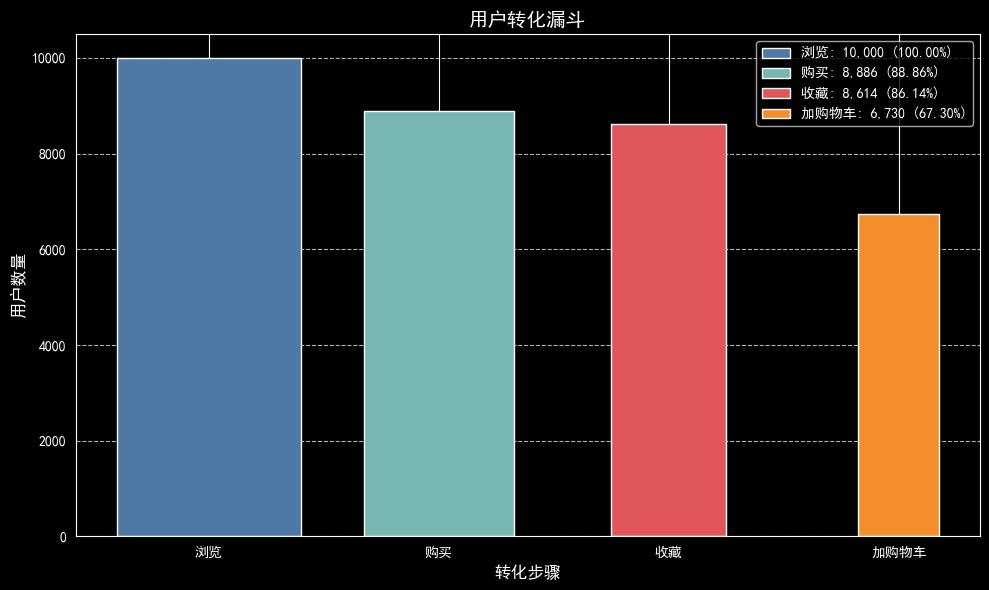

In [4]:
plot_conversion_funnel(df)

## 4.分步骤漏斗分析

In [5]:
# 分析用户路径
user_behavior = df.groupby('user_id')['behavior_type'].unique().reset_index()

# 定义典型路径
paths = {
    'pv_only': lambda x: set(x) == {1},
    'pv_cart': lambda x: 1 in x and 2 in x and 4 not in x,
    'pv_favorite': lambda x: 1 in x and 3 in x and 4 not in x,
    'pv_cart_buy': lambda x: 1 in x and 2 in x and 4 in x,
    'pv_favorite_buy': lambda x: 1 in x and 3 in x and 4 in x,
    'pv_cart_favorite_buy': lambda x: 1 in x and 2 in x and 3 in x and 4 in x,
    'direct_buy': lambda x: 4 in x and 1 not in x
}

# 统计各路径用户数
path_counts = {}
for path_name, condition in paths.items():
    count = user_behavior[user_behavior['behavior_type'].apply(condition)].shape[0]
    path_counts[path_name] = count

print("=== 用户路径分布 ===")
for path, count in sorted(path_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{path}: {count:,} 人 ({count/len(user_behavior)*100:.2f}%)")

=== 用户路径分布 ===
pv_favorite_buy: 8,034 人 (80.34%)
pv_cart_buy: 6,256 人 (62.56%)
pv_cart_favorite_buy: 5,739 人 (57.39%)
pv_favorite: 580 人 (5.80%)
pv_cart: 474 人 (4.74%)
pv_only: 341 人 (3.41%)
direct_buy: 0 人 (0.00%)
